# Presentation

This Notebook presents the results for the Relative himidity study. The objective was to observe the fluctuation of this meteorological parameter to catch an eventual trend(s) due to global warming. In addition, this study could be link with temperature or wind studies in order to create links between parameters and global warming.

# Imports

In [1]:
import os

from packages.mining import open_data
from packages.plotting import plot_data
from packages.computing import climatology, quantiles, clim_ma, thresholds, thresholds_serie, ma_quantiles, season_box

directory = os.chdir("/home/leopaul/Climate_Change_PO/")

# General view

In [2]:
sr = open_data(
    "data/FRNOR.RR2025010565429.PPDH.KEYuAAuu91dxAxu2BfU7xuA.csv",
    "U"
)

/home/leopaul/Climate_Change_PO/packages/mining.py:23: DtypeWarning: Columns (2,3,6,7,9,10,11,13,17,18,19,21,23,24,25,27,29,40,41,45,49,51,53,55,57,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, sep=';', encoding='utf-8')


DatetimeIndex(['1930-08-01 00:00:00', '1930-08-01 03:00:00',
               '1930-08-01 06:00:00', '1930-08-01 09:00:00',
               '1930-08-01 12:00:00', '1930-08-01 15:00:00',
               '1930-08-01 21:00:00', '1930-08-02 00:00:00',
               '1930-08-02 03:00:00', '1930-08-02 06:00:00',
               ...
               '2025-06-28 03:00:00', '2025-06-28 06:00:00',
               '2025-06-28 09:00:00', '2025-06-28 12:00:00',
               '2025-06-28 15:00:00', '2025-06-28 18:00:00',
               '2025-06-28 21:00:00', '2025-06-29 00:00:00',
               '2025-06-29 03:00:00', '2025-06-29 06:00:00'],
              dtype='datetime64[ns]', name='DATE', length=46223, freq=None)


In [3]:
sr_stdy = sr.loc["1960-01-01 00:00:00":"2019-12-31 23:00:00"]
dates_nan = sr_stdy[sr_stdy.isna()].index
nan_by_year = sr_stdy.isna().groupby(sr_stdy.index.year).sum()
nan_by_year = nan_by_year[nan_by_year != 0]
print(nan_by_year)
print(dates_nan)

DATE
1966     1
2005     2
2012     1
2013     2
2014     1
2016     3
2017     7
2019    45
Name: U, dtype: int64
DatetimeIndex(['1966-12-11 21:00:00', '2005-03-17 00:00:00',
               '2005-03-17 03:00:00', '2012-02-04 03:00:00',
               '2013-07-18 00:00:00', '2013-07-18 03:00:00',
               '2014-09-12 09:00:00', '2016-09-04 00:00:00',
               '2016-09-04 03:00:00', '2016-09-04 06:00:00',
               '2017-01-28 00:00:00', '2017-01-28 03:00:00',
               '2017-02-05 21:00:00', '2017-02-06 00:00:00',
               '2017-02-06 03:00:00', '2017-02-06 06:00:00',
               '2017-02-06 09:00:00', '2019-06-04 09:00:00',
               '2019-07-26 18:00:00', '2019-07-26 21:00:00',
               '2019-07-27 00:00:00', '2019-07-27 03:00:00',
               '2019-07-27 06:00:00', '2019-07-27 09:00:00',
               '2019-07-27 12:00:00', '2019-07-27 15:00:00',
               '2019-07-27 18:00:00', '2019-07-27 21:00:00',
               '2019-07-28 00:0

DATE
2019    3
Name: U, dtype: int64
DatetimeIndex(['2019-07-27', '2019-07-28', '2019-08-18'], dtype='datetime64[ns]', name='DATE', freq=None)


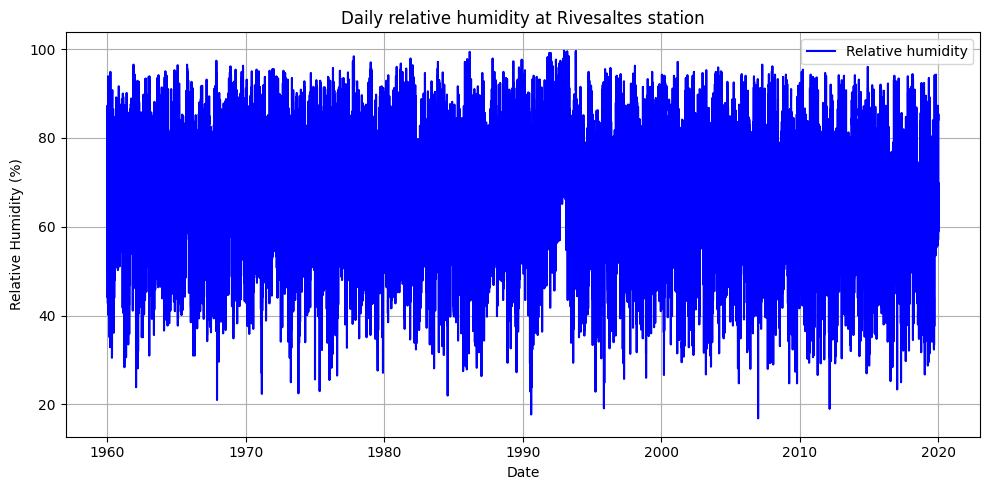

In [4]:
sr_d = sr_stdy.resample("D").mean()
dates_nan = sr_d[sr_d.isna()].index
nan_by_year = sr_d.isna().groupby(sr_d.index.year).sum()
nan_by_year = nan_by_year[nan_by_year != 0]
print(nan_by_year)
print(dates_nan)
plot_data(
    sr_d,
    "Relative humidity",
    "Daily relative humidity",
    "humidity/daily_humidity"
)

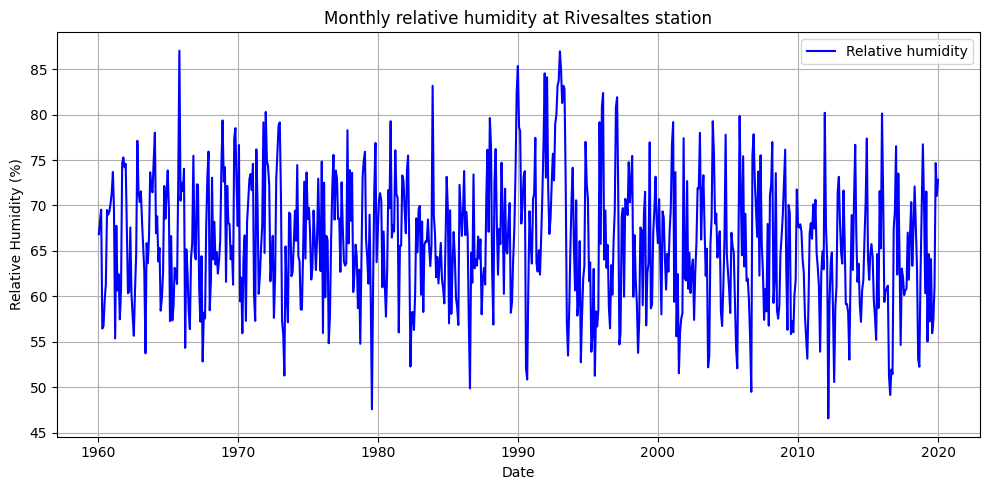

In [5]:
sr_m = sr_stdy.resample("ME").mean()
plot_data(
    sr_m,
    "Relative humidity",
    "Monthly relative humidity",
    "humidity/monthly_humidity"
)

# Climatology

## Normal

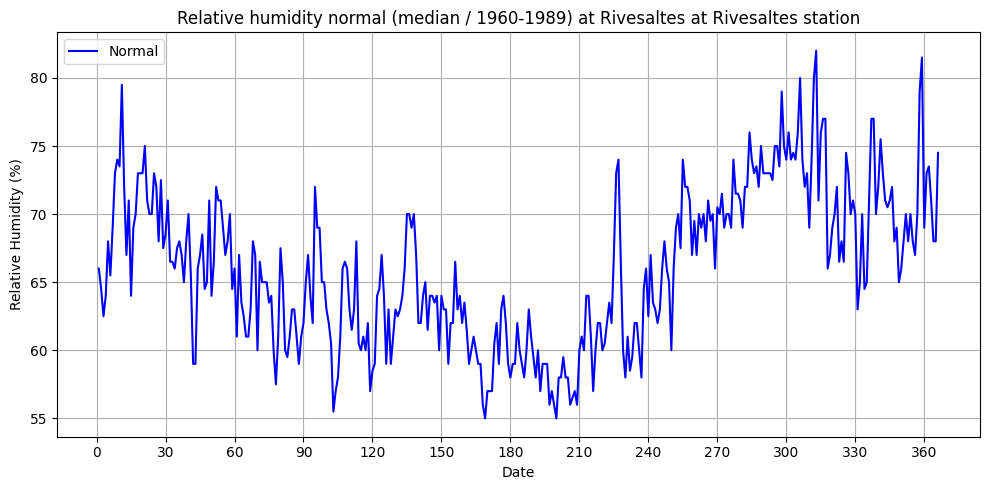

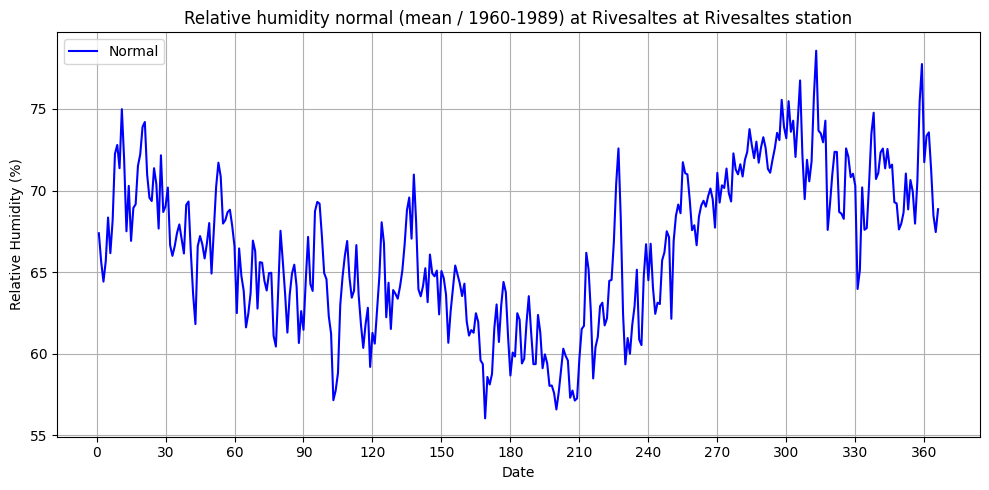

In [6]:
(sr_clim_frst_med, sr_clim_frst_mean) = climatology(
    sr_stdy,
    "1960-01-01 00:00:00",
    "1989-12-31 23:00:00",
    "Relative humidity",
    "humidity"
)

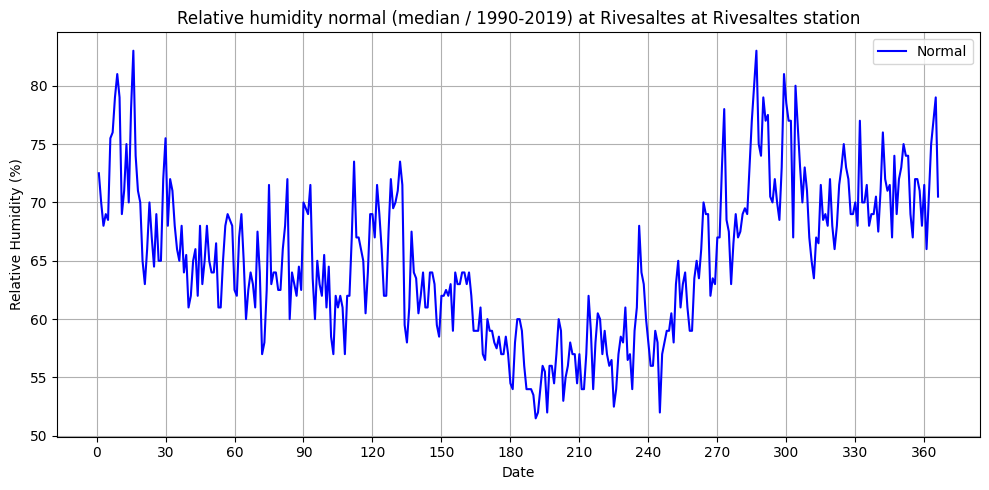

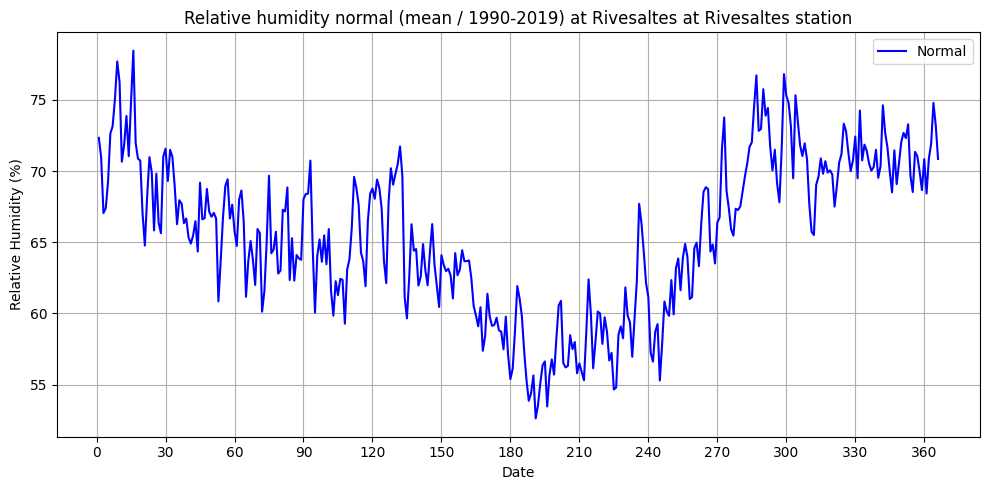

In [7]:
(sr_clim_frst_med, sr_clim_frst_mean) = climatology(
    sr_stdy,
    "1990-01-01 00:00:00",
    "2019-12-31 23:00:00",
    "Relative humidity",
    "humidity"
)

## Quantiles

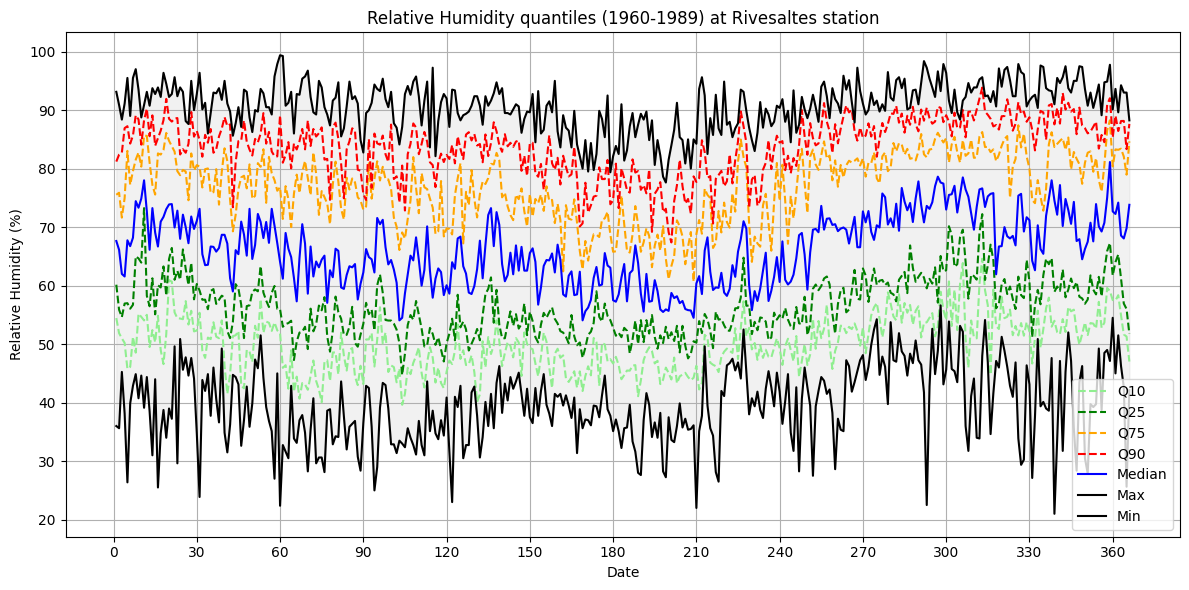

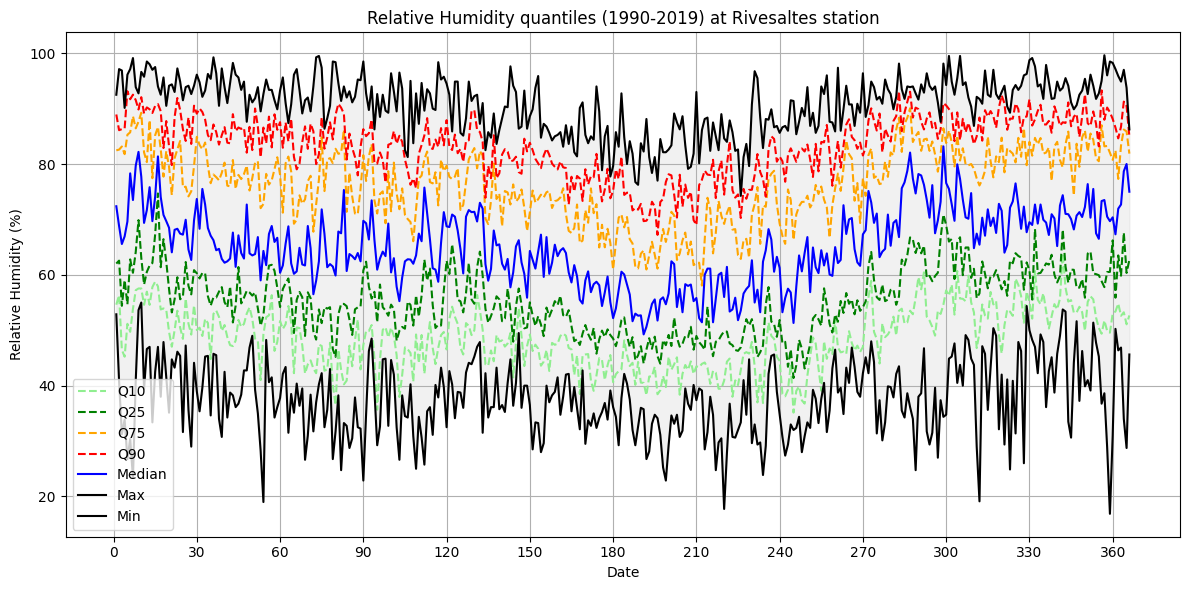

In [8]:
sr_frst = sr_stdy.loc["1960-01-01 00:00:00":"1989-12-31 23:00:00"]
sr_snd = sr_stdy.loc["1990-01-01 00:00:00":"2019-12-31 23:00:00"]

dic_q_frst = quantiles(
    sr_frst,
    "avg",
    "Relative Humidity quantiles (1960-1989) at Rivesaltes station",
    "Relative Humidity (%)",
    "humidity/quantiles_1960_1989"
)

dic_q_frst = quantiles(
    sr_snd,
    "avg",
    "Relative Humidity quantiles (1990-2019) at Rivesaltes station",
    "Relative Humidity (%)",
    "humidity/quantiles_1990_2019"
)

## Moving average

### Normal

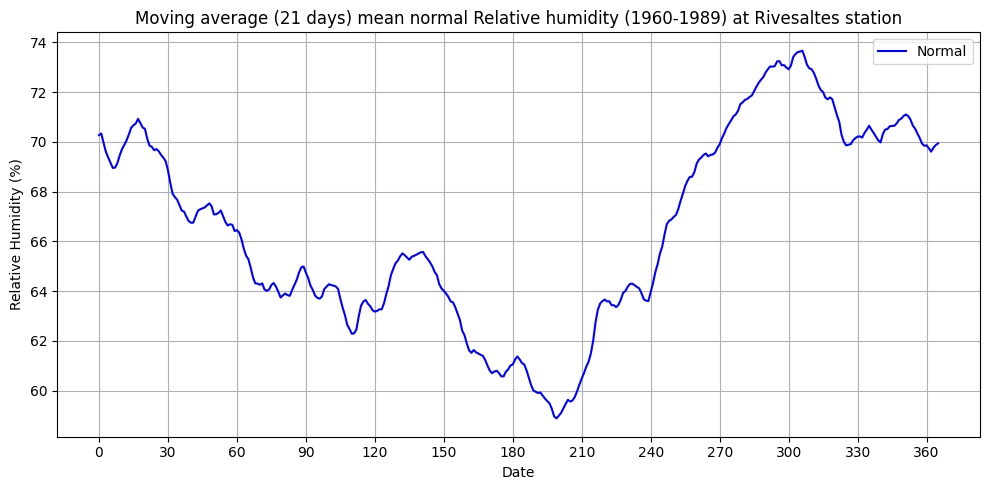

In [9]:
sr_nrm = clim_ma(
    sr,
    "Relative humidity",
    21,
    "mean",
    "1960-01-01 00:00:00",
    "1989-12-31 23:00:00",
    "humidity",
    True
)

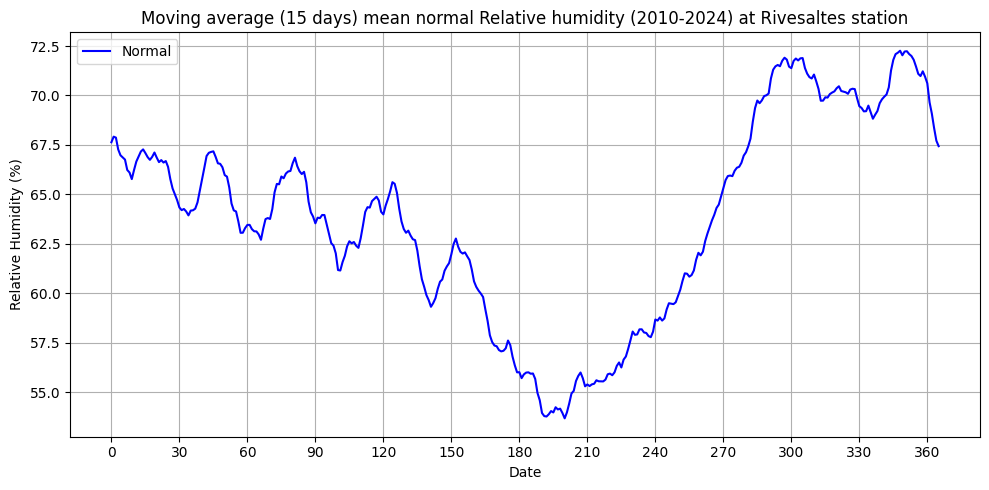

In [10]:
sr_nrm = clim_ma(
    sr,
    "Relative humidity",
    15,
    "mean",
    "2010-01-01 00:00:00",
    "2024-12-31 23:00:00",
    "humidity",
    True
)

### Quantiles

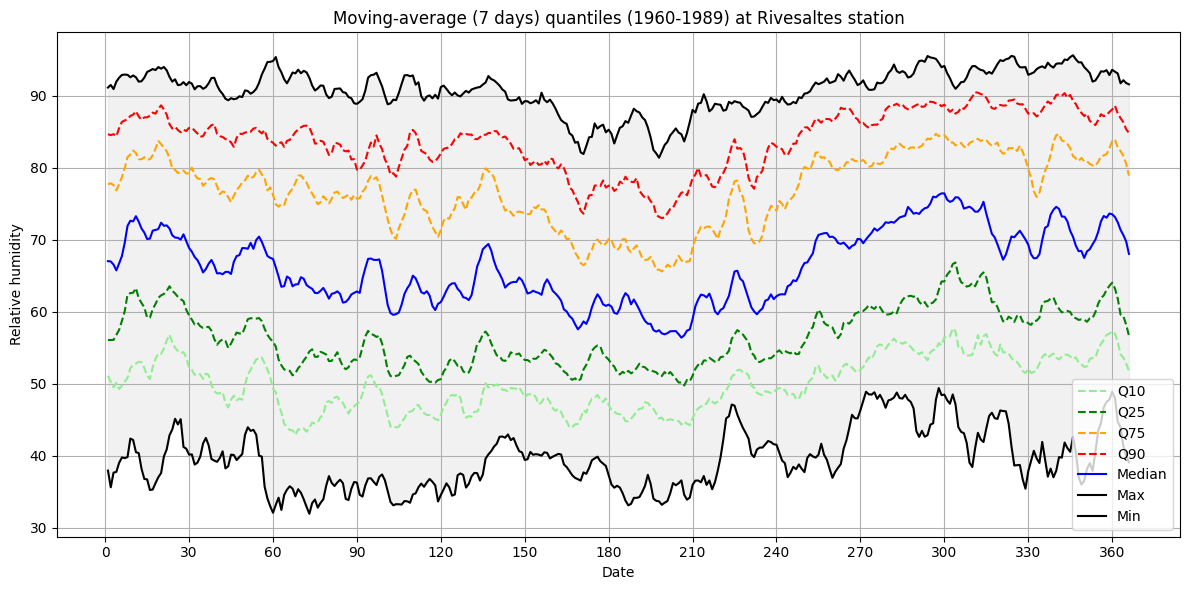

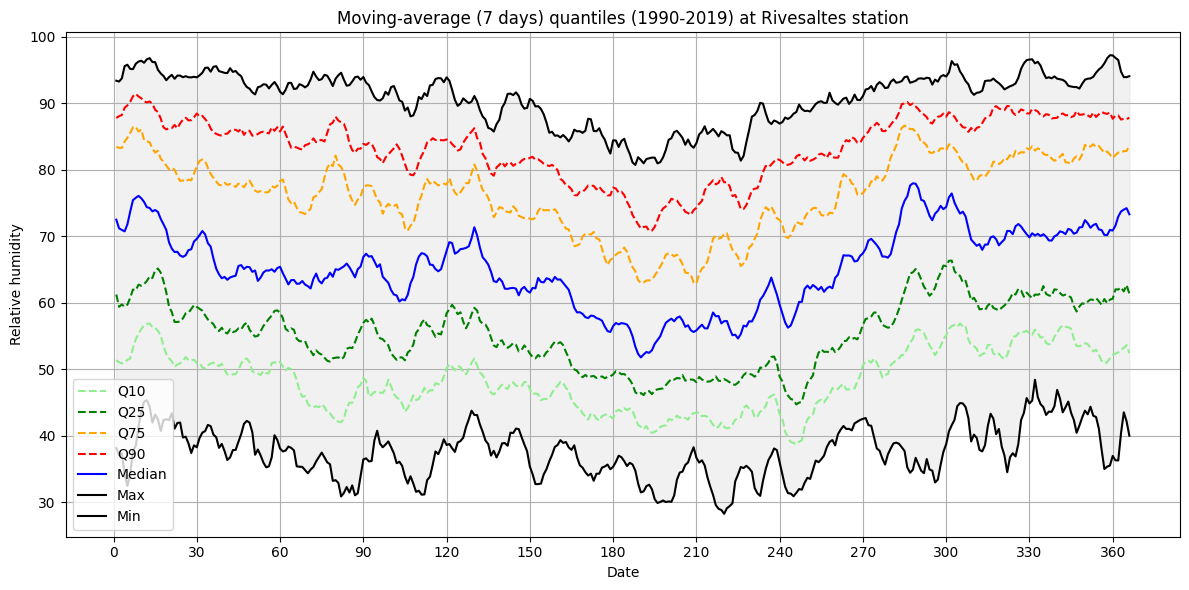

In [11]:
dic_ma_q_f = ma_quantiles(
    sr,
    7,
    "avg",
    "1960-01-01 00:00:00",
    "1989-12-31 23:00:00",
    "Moving-average (7 days) quantiles (1960-1989) at Rivesaltes station",
    "Relative humidity",
    "humidity"
)

dic_ma_q_s = ma_quantiles(
    sr,
    7,
    "avg",
    "1990-01-01 00:00:00",
    "2019-12-31 23:00:00",
    "Moving-average (7 days) quantiles (1990-2019) at Rivesaltes station",
    "Relative humidity",
    "humidity"
)

## Thresholds

Numbre of days with relative humidity < 50% for 1960-1989 : 215
The corresponding dates are : [Timestamp('1960-01-13 00:00:00'), Timestamp('1960-01-15 00:00:00'), Timestamp('1960-01-18 00:00:00'), Timestamp('1960-01-30 00:00:00'), Timestamp('1960-02-01 00:00:00'), Timestamp('1961-02-10 00:00:00'), Timestamp('1961-12-15 00:00:00'), Timestamp('1962-01-28 00:00:00'), Timestamp('1962-01-29 00:00:00'), Timestamp('1962-01-30 00:00:00'), Timestamp('1962-01-31 00:00:00'), Timestamp('1962-02-01 00:00:00'), Timestamp('1962-02-02 00:00:00'), Timestamp('1962-02-11 00:00:00'), Timestamp('1962-02-14 00:00:00'), Timestamp('1962-02-15 00:00:00'), Timestamp('1962-02-16 00:00:00'), Timestamp('1962-02-17 00:00:00'), Timestamp('1962-02-18 00:00:00'), Timestamp('1963-01-13 00:00:00'), Timestamp('1963-01-14 00:00:00'), Timestamp('1963-01-26 00:00:00'), Timestamp('1963-01-27 00:00:00'), Timestamp('1963-01-28 00:00:00'), Timestamp('1963-02-01 00:00:00'), Timestamp('1963-02-21 00:00:00'), Timestamp('1963-12-14

<Figure size 600x500 with 0 Axes>

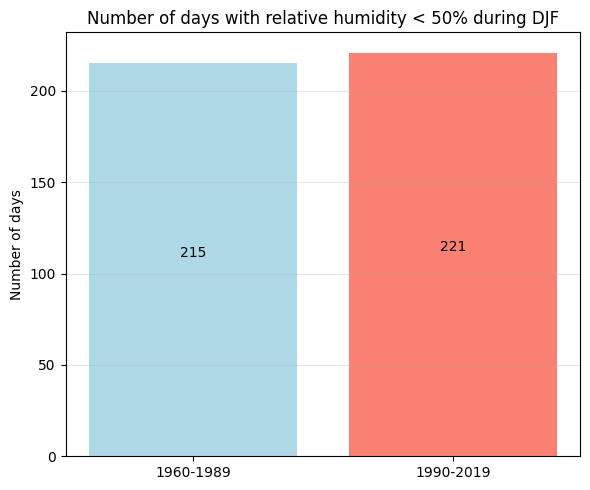

In [12]:
sr_thresholds_d = sr.resample("D").mean()

sr_frst_d = sr_thresholds_d.loc["1960-01-01 00:00:00":"1989-12-31 23:00:00"]
sr_snd_d = sr_thresholds_d.loc["1990-01-01 00:00:00":"2019-12-31 23:00:00"]
thresholds(
    variable="relative humidity",
    months=[12, 1, 2],
    first_sr=sr_frst_d,
    second_sr=sr_snd_d,
    threshold=50,
    study_sign="<"
)

Numbre of days with relative humidity < 50% for 1960-1980 : 136
The corresponding dates are : [Timestamp('1960-01-13 00:00:00'), Timestamp('1960-01-15 00:00:00'), Timestamp('1960-01-18 00:00:00'), Timestamp('1960-01-30 00:00:00'), Timestamp('1960-02-01 00:00:00'), Timestamp('1961-02-10 00:00:00'), Timestamp('1961-12-15 00:00:00'), Timestamp('1962-01-28 00:00:00'), Timestamp('1962-01-29 00:00:00'), Timestamp('1962-01-30 00:00:00'), Timestamp('1962-01-31 00:00:00'), Timestamp('1962-02-01 00:00:00'), Timestamp('1962-02-02 00:00:00'), Timestamp('1962-02-11 00:00:00'), Timestamp('1962-02-14 00:00:00'), Timestamp('1962-02-15 00:00:00'), Timestamp('1962-02-16 00:00:00'), Timestamp('1962-02-17 00:00:00'), Timestamp('1962-02-18 00:00:00'), Timestamp('1963-01-13 00:00:00'), Timestamp('1963-01-14 00:00:00'), Timestamp('1963-01-26 00:00:00'), Timestamp('1963-01-27 00:00:00'), Timestamp('1963-01-28 00:00:00'), Timestamp('1963-02-01 00:00:00'), Timestamp('1963-02-21 00:00:00'), Timestamp('1963-12-14

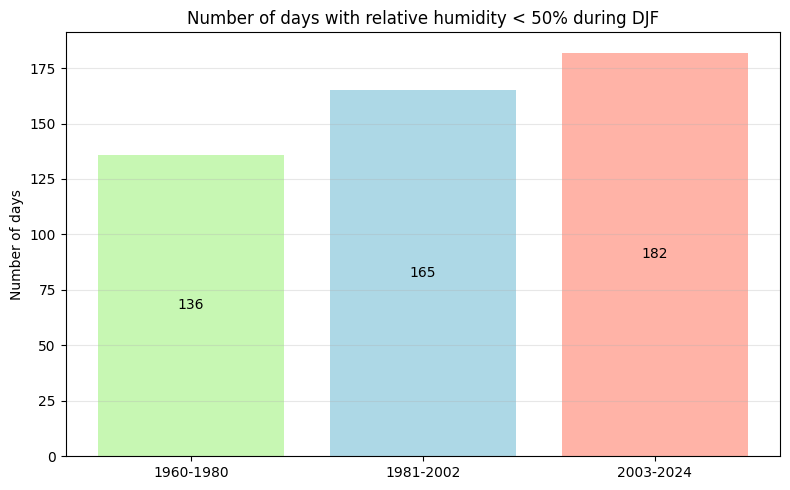

In [13]:
sr_twenty_f = sr_thresholds_d.loc["1960-01-01 00:00:00":"1980-12-31 23:00:00"]
sr_twenty_s = sr_thresholds_d.loc["1981-01-01 00:00:00":"2002-12-31 23:00:00"]
sr_twenty_t = sr_thresholds_d.loc["2003-01-01 00:00:00":"2024-12-31 23:00:00"]
list_max = [sr_twenty_f, sr_twenty_s, sr_twenty_t]

dic_count_max_djf = thresholds_serie(
    "relative humidity",
    [12, 1, 2],
    list_max,
    threshold=50,
    study_sign="<"
)

## Monthly study

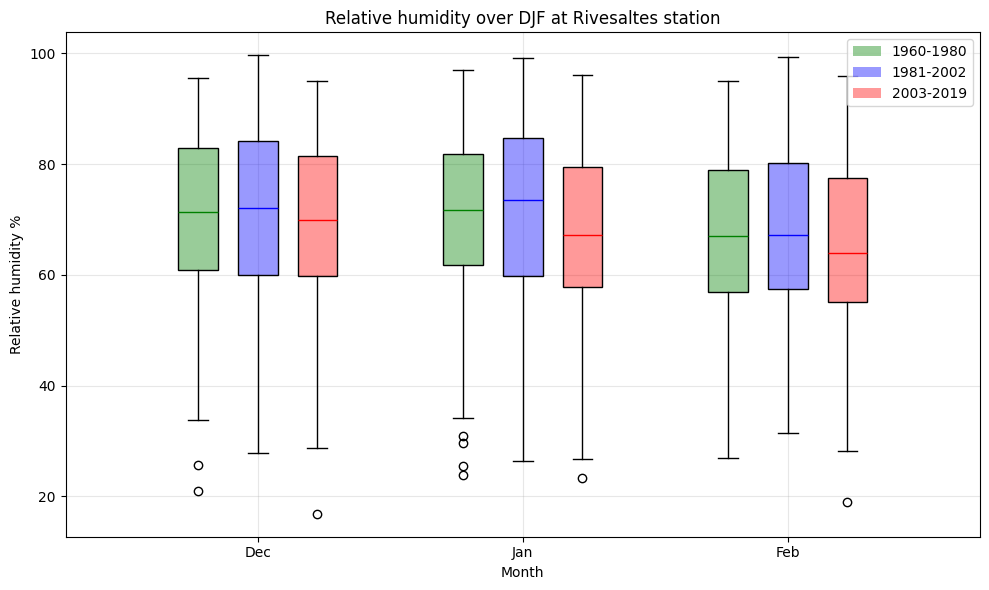

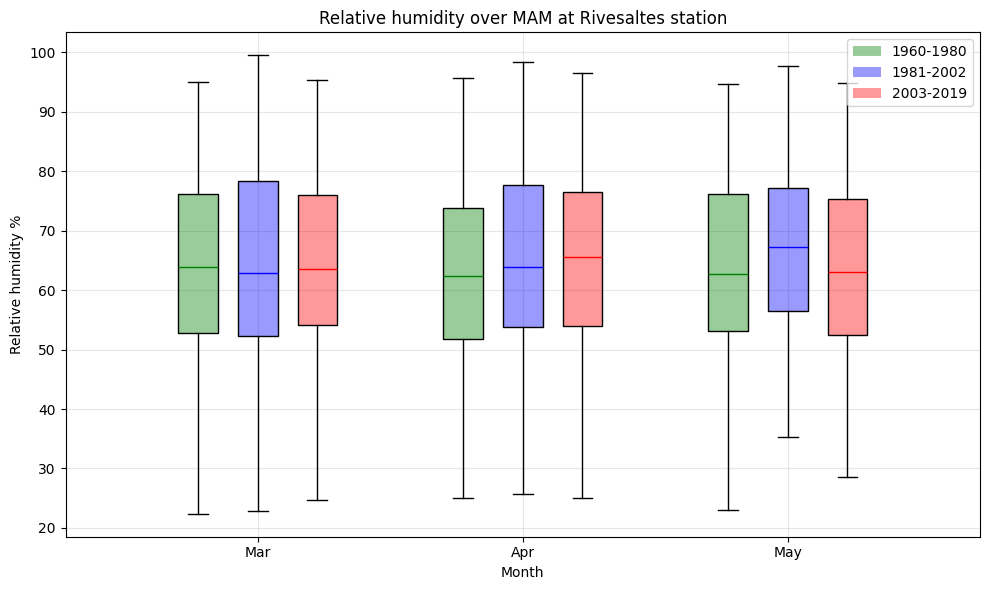

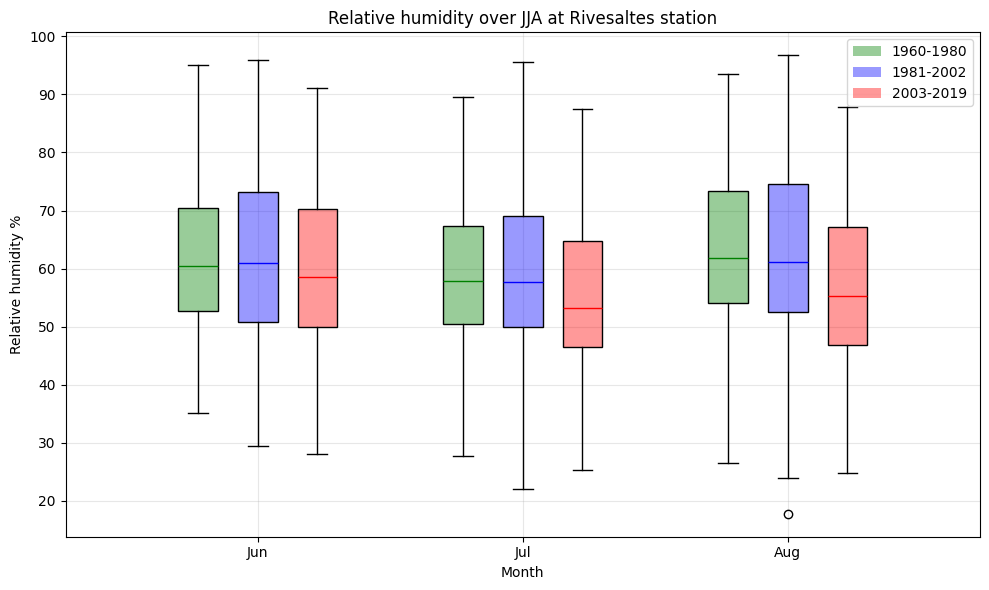

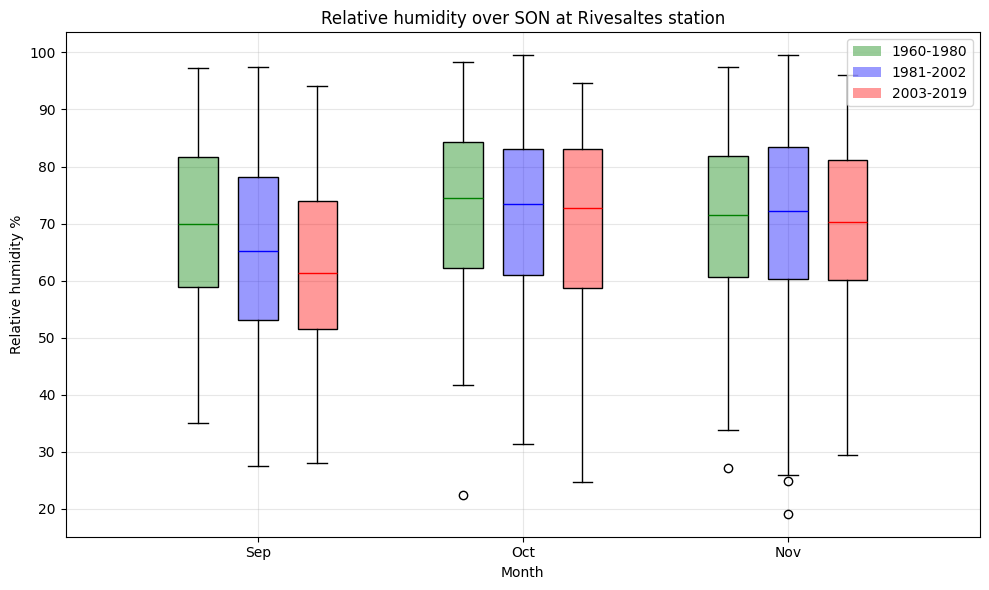

In [14]:
sr_frst_m = sr_d.loc["1960-01-31":"1980-12-31"]
sr_snd_m = sr_d.loc["1981-01-31":"2002-12-31"]
sr_thd_m = sr_d.loc["2003-01-31":"2024-12-31"]
sr_thd_m = sr_thd_m.dropna()
list_sr_m = [sr_frst_m, sr_snd_m, sr_thd_m] 

season_box (
    list_sr_m,
    (12, 1, 2),
    "Relative humidity %",
    "Relative humidity over DJF at Rivesaltes station",
    "humidity" 
)

season_box (
    list_sr_m,
    (3, 4, 5),
    "Relative humidity %",
    "Relative humidity over MAM at Rivesaltes station",
    "humidity" 
)

season_box (
    list_sr_m,
    (6, 7, 8),
    "Relative humidity %",
    "Relative humidity over JJA at Rivesaltes station",
    "humidity" 
)

season_box (
    list_sr_m,
    (9, 10, 11),
    "Relative humidity %",
    "Relative humidity over SON at Rivesaltes station",
    "humidity" 
)